# LLA: Effect of Similarity Function on Clustering

The Laplace Last-Layer Approximation (LLA) produces post-hoc uncertainty
from a trained NonLinear model. The **mean** embeddings are identical to
NonLinear; only the **variance** differs.

The key question: which similarity function best exploits LLA variance for clustering?

| k_form | Similarity formula | Role of $\alpha$ | Expected behavior with LLA |
|--------|-------------------|-------------------|---------------------------|
| `adaptive` | $\exp\!\bigl(-s \sum_d \delta_d^2 / (v_{i,d}+v_{j,d}+\alpha)\bigr)$ | Regularizer: $\alpha=0$ pure Mahalanobis, large $\alpha \to$ Euclidean | Controls how much per-dimension variance influences distance |
| `identity` | $\exp\!\bigl(-s \sum_d [\tfrac{1}{2}\log(v_d/\alpha+1) + \tfrac{1}{2}\delta_d^2/(v_d+\alpha)]\bigr)$ | Noise floor: large $\alpha \to$ variance ignored | Log-penalty may help penalize uncertain pairs |
| `expected_distance` | $\exp\!\bigl(-s (\sum_d \delta_d^2 + \sum_d v_d)\bigr)$ | No $\alpha$ in sim (auto-scaled) | Variance as additive cost — uncertain pairs get lower similarity |
| det. L2 | $\exp(-s \|\delta\|^2)$ | N/A | Baseline: ignore variance entirely |

The `scale` $s$ is always **auto-calibrated** so that median intra-class similarity $\approx 0.5$.
We sweep $\alpha$ for adaptive and identity forms.

**Important:** $\alpha$ values should be chosen relative to the LLA variance magnitude.
For this dataset, LLA variances are $\sim 10^{-3}$, so $\alpha$ is swept from $10^{-4}$
to $10^{-1}$ to cover the interesting regime.

## Setup

In [1]:
import sys, os, csv, tempfile, json
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

from embedders.nonlinear import NonLinearEmbedder, set_seed
from embedders.laplace_embedder import LaplaceLastLayerEmbedder
from embedders.base import EmbeddingResult
from datasets.paired_reads import PairedReadsDataset
from clustering.kmedoid import KMedoidClusterer
from evaluation.eval_utils import (
    align_labels_via_hungarian_algorithm,
    count_high_quality_clusters,
    compute_class_center_medium_similarity,
)
from embedders.nonlinear import contrastive_loss
import sklearn.metrics

SEED = 26042024
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_TSV = '../../data/dnabert/eval/reference/clustering_0.tsv'
TRAIN_FRAC = 0.7
MODEL_DIR = '../../models/notebook'

METRIC = 'l2'
MIN_BIN_SIZE = 5
KMEDOID_METHOD = 'alternate'

print(f'Device: {DEVICE}')

Device: cuda


## Data Loading

In [2]:
csv.field_size_limit(min(sys.maxsize, 2**31 - 1))
with open(DATA_TSV) as f:
    reader = csv.reader(f, delimiter='\t')
    header = next(reader)
    all_rows = list(reader)

sequences = [r[0] for r in all_rows]
labels_str = [r[1] for r in all_rows]
unique_labels = sorted(set(labels_str))

rng = np.random.RandomState(SEED)
species_to_idx = defaultdict(list)
for i, lab in enumerate(labels_str):
    species_to_idx[lab].append(i)

train_idx, test_idx = [], []
for lab in unique_labels:
    idxs = np.array(species_to_idx[lab])
    rng.shuffle(idxs)
    split = int(len(idxs) * TRAIN_FRAC)
    train_idx.extend(idxs[:split].tolist())
    test_idx.extend(idxs[split:].tolist())

train_seqs = [sequences[i] for i in train_idx]
train_labels = [labels_str[i] for i in train_idx]
test_seqs = [sequences[i] for i in test_idx]
test_labels_str = [labels_str[i] for i in test_idx]

lab2id = {l: i for i, l in enumerate(unique_labels)}
train_labels_num = np.array([lab2id[l] for l in train_labels])
test_labels = np.array([lab2id[l] for l in test_labels_str])
n_species = len(unique_labels)

# Build contrastive pairs for LLA fitting
train_by_species = defaultdict(list)
for seq, lab in zip(train_seqs, train_labels):
    train_by_species[lab].append(seq)

train_csv_path = os.path.join(tempfile.gettempdir(), 'genome_train_pairs.csv')
n_pairs = 0
with open(train_csv_path, 'w') as f:
    for lab in unique_labels:
        seqs = train_by_species[lab]
        for i in range(0, len(seqs) - 1, 2):
            f.write(f'{seqs[i]},{seqs[i + 1]}\n')
            n_pairs += 1

print(f'Total: {len(sequences)} sequences, {n_species} species')
print(f'Train: {len(train_seqs)}, Test: {len(test_seqs)}, Pairs: {n_pairs}')

Total: 20000 sequences, 200 species
Train: 14000, Test: 6000, Pairs: 7000


## Load NonLinear + Fit LLA

In [3]:
set_seed(SEED)

model_nl = NonLinearEmbedder.load(os.path.join(MODEL_DIR, 'nonlinear.model'), device=DEVICE)
print(f'NonLinear loaded')

# Fit or load LLA
LLA_PATH = os.path.join(MODEL_DIR, 'lla_state.pt')
model_lla = LaplaceLastLayerEmbedder(model_nl)

if os.path.exists(LLA_PATH):
    lla_state = torch.load(LLA_PATH, map_location=DEVICE, weights_only=True)
    model_lla.Q_A = lla_state['Q_A']
    model_lla.Q_B = lla_state['Q_B']
    model_lla.S_A = lla_state['S_A']
    model_lla.S_B = lla_state['S_B']
    model_lla.prior_precision = lla_state['prior_precision']
    model_lla.n_data = lla_state['n_data']
    model_lla._fitted = True
    print(f'Loaded LLA from {LLA_PATH} (prior={model_lla.prior_precision:.2f})')
else:
    dataset = PairedReadsDataset(
        file_path=train_csv_path,
        transform_func=model_nl._feature_extractor.extract,
        neg_sample_per_pos=20, max_read_num=0, seed=SEED,
    )
    model_lla.fit(
        dataset, loss_fn=contrastive_loss, batch_size=256,
        device=DEVICE, loss_name='bern', hessian_factorization='ggn',
    )
    model_lla.optimize_prior(method='mackay')
    print(f'LLA prior precision: {model_lla.prior_precision:.4f}')
    torch.save({
        'Q_A': model_lla.Q_A, 'Q_B': model_lla.Q_B,
        'S_A': model_lla.S_A, 'S_B': model_lla.S_B,
        'prior_precision': model_lla.prior_precision,
        'n_data': model_lla.n_data,
    }, LLA_PATH)
    print(f'Saved LLA -> {LLA_PATH}')

NonLinear loaded
Loaded LLA from ../models/notebook\lla_state.pt (prior=5347.31)


## Embed Train + Test

In [4]:
# NonLinear (deterministic)
train_emb_nl = model_nl.embed(train_seqs)
test_emb_nl = model_nl.embed(test_seqs)

# LLA (probabilistic — same means as NonLinear, different variance)
train_emb_lla = model_lla.embed(train_seqs)
test_emb_lla = model_lla.embed(test_seqs)

print(f'NonLinear: mean {test_emb_nl.mean.shape}')
print(f'LLA:       mean {test_emb_lla.mean.shape}, var {test_emb_lla.variance.shape}')
print(f'           var range: [{test_emb_lla.variance.min():.6f}, {test_emb_lla.variance.max():.6f}]')
print(f'           var mean:  {test_emb_lla.variance.mean():.6f}')

NonLinear: mean (6000, 256)
LLA:       mean (6000, 256), var (6000, 256)
           var range: [0.000676, 0.008541]
           var mean:  0.001660


## Evaluate All Similarity Configurations

We test every combination of `(k_form, alpha)` plus the deterministic baseline.
Scale $s$ is auto-calibrated for each configuration.

In [5]:
# --- Configuration ---
# LLA variances are ~0.001-0.009 (mean ~0.003 for combined pairs).
# Alpha must span this range to see its effect.
alphas_sweep = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1]

configs = []
# Deterministic L2 (ignore variance)
configs.append(('det_l2', None, 'Det. L2'))
# Adaptive with alpha sweep
for a in alphas_sweep:
    configs.append(('adaptive', a, f'Adaptive a={a}'))
# Identity with alpha sweep
for a in alphas_sweep:
    configs.append(('identity', a, f'Identity a={a}'))
# Expected distance (no alpha in similarity)
configs.append(('expected_distance', 1.0, 'Exp. Distance'))

results = {}

for k_form, alpha, label in configs:
    print(f'\n--- {label} ---')

    if k_form == 'det_l2':
        # Deterministic: use point estimates only
        pv, sc = compute_class_center_medium_similarity(
            train_emb_lla.point_estimate, train_labels_num, metric=METRIC)
        threshold = pv[-3]
        kmed = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                                 scale=sc, method=KMEDOID_METHOD)
        emb_det = EmbeddingResult(mean=test_emb_lla.mean)
        pred = kmed.fit_predict(emb_det, min_similarity=threshold)
    else:
        # Probabilistic: use variance with specified k_form
        pv, sc = compute_class_center_medium_similarity(
            train_emb_lla.point_estimate, train_labels_num, metric=METRIC,
            variances=train_emb_lla.variance, k_form=k_form, alpha=alpha)
        threshold = pv[-3]
        kmed = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                                 scale=sc, method=KMEDOID_METHOD,
                                 k_form=k_form, alpha=alpha)
        pred = kmed.fit_predict(test_emb_lla, min_similarity=threshold)

    r = count_high_quality_clusters(test_labels, pred)
    k = len(set(pred[pred != -1].tolist())) if (pred != -1).any() else 0
    assigned = int((pred != -1).sum())
    coverage = assigned / len(test_labels)

    results[label] = {
        'k_form': k_form, 'alpha': alpha, 'pred': pred, 'r': r,
        'k': k, 'assigned': assigned, 'coverage': coverage,
        'scale': sc, 'threshold': threshold, 'percentiles': pv,
    }
    print(f'  scale={sc:.6f}  k={k}  assigned={assigned}/{len(test_labels)} ({coverage:.1%})  '
          f'F1>0.5={r["counts"][4]}  F1>0.7={r["counts"][6]}')


--- Det. L2 ---
Auto-calibrated scale: 2.997387 (median raw distance: 0.2313)
Percentile values: [0.12450093482649371, 0.2280380439922255, 0.3230909830239522, 0.41105853727277486, 0.5000850313731194, 0.5835276401654267, 0.6581730939166871, 0.73087140859097, 0.8041553183219755]
KMedoids: k_est=123, n=6000, method=alternate
  scale=2.997387  k=121  assigned=5993/6000 (99.9%)  F1>0.5=40  F1>0.7=18

--- Adaptive a=0.0001 ---
Auto-calibrated scale: 0.009017 (median raw distance: 76.8734)
Percentile values: [0.10223274677991867, 0.2016826570034027, 0.30035513639450073, 0.40170058608055115, 0.5000160932540894, 0.5892230868339539, 0.6724860668182373, 0.7450234293937683, 0.8225076794624329]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [00:38<00:00]


KMedoids: k_est=118, n=6000, method=alternate
  scale=0.009017  k=94  assigned=5951/6000 (99.2%)  F1>0.5=18  F1>0.7=8

--- Adaptive a=0.0005 ---
Auto-calibrated scale: 0.010215 (median raw distance: 67.8565)
Percentile values: [0.10582945495843887, 0.20590625703334808, 0.30355536937713623, 0.4029242694377899, 0.5000306367874146, 0.58771151304245, 0.6718438267707825, 0.7443345785140991, 0.8203417658805847]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [00:37<00:00]


KMedoids: k_est=119, n=6000, method=alternate
  scale=0.010215  k=100  assigned=5957/6000 (99.3%)  F1>0.5=20  F1>0.7=7

--- Adaptive a=0.001 ---
Auto-calibrated scale: 0.011692 (median raw distance: 59.2857)
Percentile values: [0.11057361960411072, 0.20947259664535522, 0.30724161863327026, 0.404730886220932, 0.5000072121620178, 0.5882667899131775, 0.6706746816635132, 0.7429061532020569, 0.8187798857688904]


...

KMedoids: k_est=50, n=6000, method=alternate
  scale=0.014941  k=49  assigned=5998/6000 (100.0%)  F1>0.5=5  F1>0.7=1

--- Identity a=0.1 ---
Auto-calibrated scale: 0.128486 (median raw distance: 5.3947)
Percentile values: [0.3729517161846161, 0.4276479482650757, 0.4588077962398529, 0.4804011583328247, 0.5000008940696716, 0.5171162486076355, 0.5344493985176086, 0.5532838702201843, 0.5783814191818237]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [01:21<00:00]


KMedoids: k_est=48, n=6000, method=alternate
  scale=0.128486  k=47  assigned=5998/6000 (100.0%)  F1>0.5=4  F1>0.7=1

--- Exp. Distance ---
Auto-calibrated scale: 0.630258 (median raw distance: 1.0998)
Percentile values: [0.37149807810783386, 0.4267495572566986, 0.45810139179229736, 0.47999247908592224, 0.5000008344650269, 0.517444372177124, 0.5348454117774963, 0.5541341304779053, 0.5793949961662292]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [00:25<00:00]


KMedoids: k_est=48, n=6000, method=alternate
  scale=0.630258  k=47  assigned=5999/6000 (100.0%)  F1>0.5=4  F1>0.7=1


### NonLinear Deterministic Baseline

In [6]:
pv_nl, scale_nl = compute_class_center_medium_similarity(
    train_emb_nl.point_estimate, train_labels_num, metric=METRIC)
threshold_nl = pv_nl[-3]
kmed_nl = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                            scale=scale_nl, method=KMEDOID_METHOD)
pred_nl = kmed_nl.fit_predict(test_emb_nl, min_similarity=threshold_nl)
r_nl = count_high_quality_clusters(test_labels, pred_nl)
k_nl = len(set(pred_nl[pred_nl != -1].tolist()))
assigned_nl = (pred_nl != -1).sum()

print(f'NonLinear: k={k_nl}, assigned={assigned_nl}/{len(test_labels)}, '
      f'F1>0.5={r_nl["counts"][4]}, F1>0.7={r_nl["counts"][6]}')

Auto-calibrated scale: 2.997387 (median raw distance: 0.2313)
Percentile values: [0.12450093482649371, 0.2280380439922255, 0.3230909830239522, 0.41105853727277486, 0.5000850313731194, 0.5835276401654267, 0.6581730939166871, 0.73087140859097, 0.8041553183219755]
KMedoids: k_est=123, n=6000, method=alternate
NonLinear: k=121, assigned=5993/6000, F1>0.5=40, F1>0.7=18


## Results

### Summary Table

In [7]:
print(f'{"Method":>22s}  {"alpha":>6s}  {"scale":>10s}  {"k":>5s}  '
      f'{"assigned":>8s}  {"cover":>6s}  {"F1>0.3":>6s}  {"F1>0.5":>6s}  {"F1>0.7":>6s}')
print('-' * 95)

for label in results:
    s = results[label]
    a_str = f'{s["alpha"]:.1f}' if s['alpha'] is not None else '--'
    print(f'{label:>22s}  {a_str:>6s}  {s["scale"]:10.6f}  {s["k"]:5d}  '
          f'{s["assigned"]:8d}  {s["coverage"]:6.1%}  '
          f'{s["r"]["counts"][2]:6d}  {s["r"]["counts"][4]:6d}  {s["r"]["counts"][6]:6d}')

print('-' * 95)
print(f'{"NonLinear (ref)":>22s}  {"--":>6s}  {scale_nl:10.6f}  {k_nl:5d}  '
      f'{int(assigned_nl):8d}  {int(assigned_nl)/len(test_labels):6.1%}  '
      f'{r_nl["counts"][2]:6d}  {r_nl["counts"][4]:6d}  {r_nl["counts"][6]:6d}')

                Method   alpha       scale      k  assigned   cover  F1>0.3  F1>0.5  F1>0.7
-----------------------------------------------------------------------------------------------
               Det. L2      --    2.997387    121      5993   99.9%      68      40      18
     Adaptive a=0.0001     0.0    0.009017     94      5951   99.2%      44      18       8
     Adaptive a=0.0005     0.0    0.010215    100      5957   99.3%      49      20       7
      Adaptive a=0.001     0.0    0.011692    105      5974   99.6%      49      22      11
      Adaptive a=0.005     0.0    0.023755    115      5981   99.7%      61      33      13
       Adaptive a=0.01     0.0    0.038689    115      5998  100.0%      55      27      15
        Adaptive a=0.1     0.1    0.308521    122      5996   99.9%      68      36      18
     Identity a=0.0001     0.0    0.001403     69      5997  100.0%      32       7       2
     Identity a=0.0005     0.0    0.002333     65      5995   99.9%      34 

### Bar Chart: F1>0.5 and F1>0.7 by Configuration

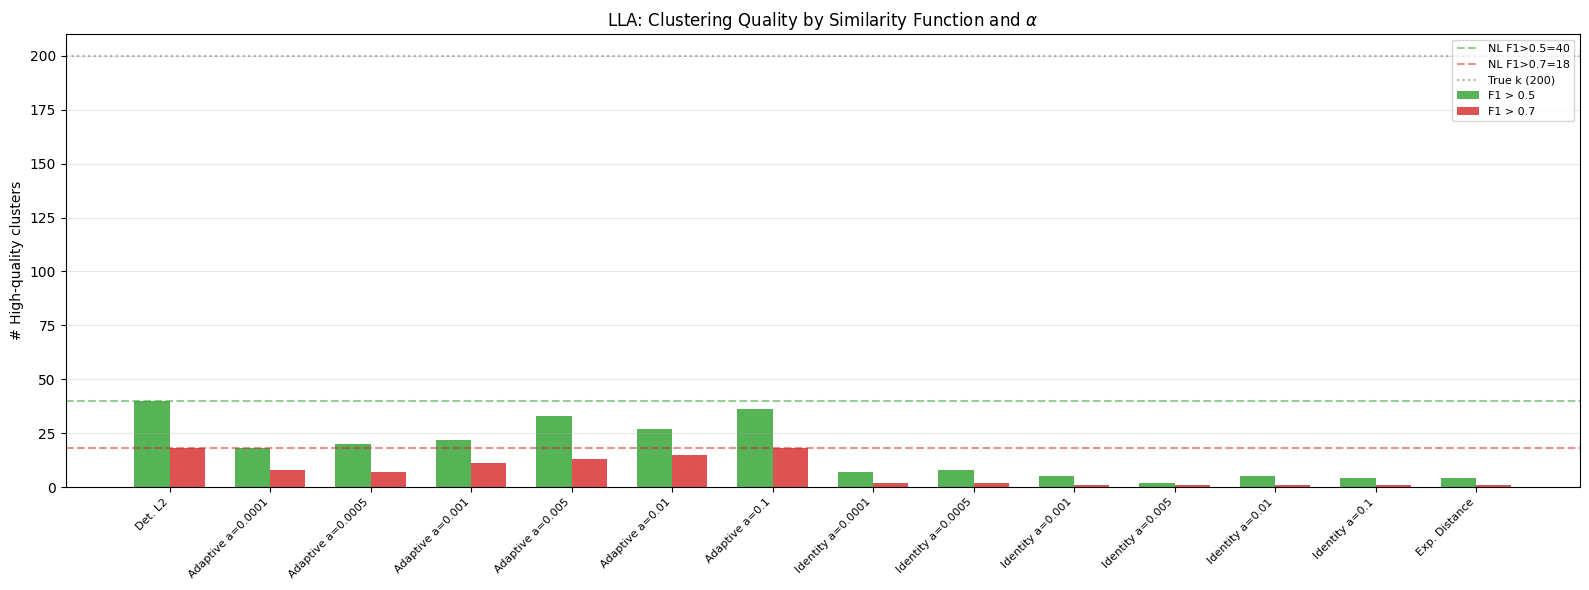

In [8]:
labels_list = list(results.keys())
f1_05 = [results[l]['r']['counts'][4] for l in labels_list]
f1_07 = [results[l]['r']['counts'][6] for l in labels_list]

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(labels_list))
width = 0.35

bars1 = ax.bar(x - width/2, f1_05, width, label='F1 > 0.5', color='tab:green', alpha=0.8)
bars2 = ax.bar(x + width/2, f1_07, width, label='F1 > 0.7', color='tab:red', alpha=0.8)

ax.axhline(r_nl['counts'][4], ls='--', color='tab:green', alpha=0.5,
           label=f'NL F1>0.5={r_nl["counts"][4]}')
ax.axhline(r_nl['counts'][6], ls='--', color='tab:red', alpha=0.5,
           label=f'NL F1>0.7={r_nl["counts"][6]}')
ax.axhline(n_species, ls=':', color='black', alpha=0.3, label=f'True k ({n_species})')

ax.set_xticks(x)
ax.set_xticklabels(labels_list, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('# High-quality clusters')
ax.set_title('LLA: Clustering Quality by Similarity Function and $\\alpha$')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### F1 vs $\alpha$ per Similarity Function

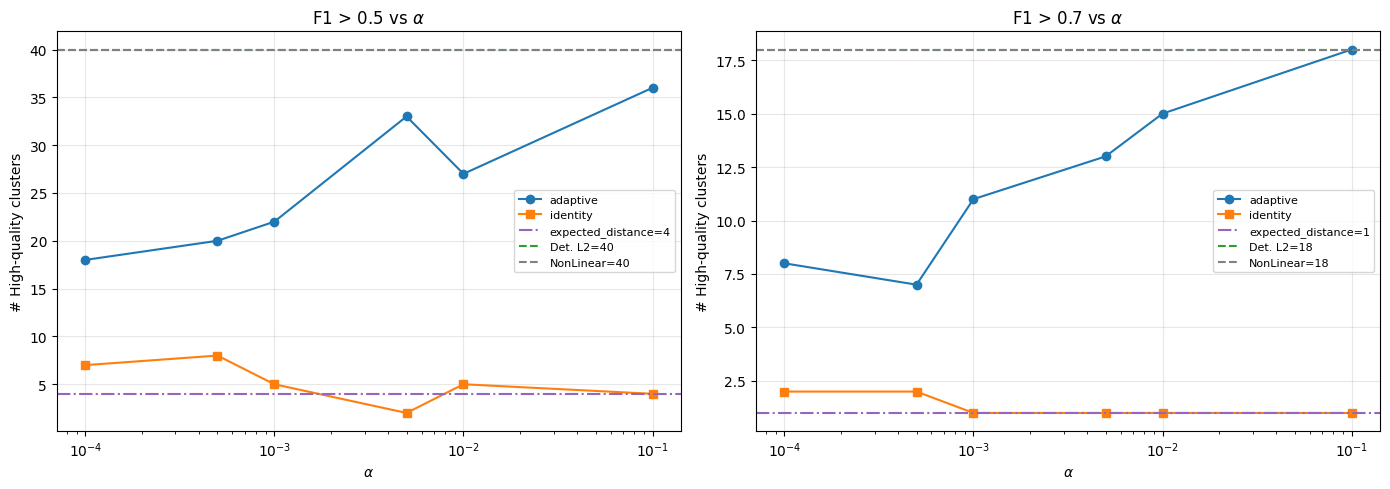

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, f1_idx, f1_label in zip(axes, [4, 6], ['F1 > 0.5', 'F1 > 0.7']):
    for k_form, color, marker in [('adaptive', 'tab:blue', 'o'),
                                   ('identity', 'tab:orange', 's')]:
        a_vals = []
        f1_vals = []
        for label, s in results.items():
            if s['k_form'] == k_form:
                a_vals.append(s['alpha'])
                f1_vals.append(s['r']['counts'][f1_idx])
        ax.semilogx(a_vals, f1_vals, f'{marker}-', color=color, label=k_form)

    # Expected distance (single point, no alpha)
    ed = results.get('Exp. Distance')
    if ed:
        ax.axhline(ed['r']['counts'][f1_idx], ls='-.', color='tab:purple',
                   label=f'expected_distance={ed["r"]["counts"][f1_idx]}')

    # Det L2 baseline
    det = results.get('Det. L2')
    if det:
        ax.axhline(det['r']['counts'][f1_idx], ls='--', color='tab:green',
                   label=f'Det. L2={det["r"]["counts"][f1_idx]}')

    # NonLinear reference
    ax.axhline(r_nl['counts'][f1_idx], ls='--', color='gray',
               label=f'NonLinear={r_nl["counts"][f1_idx]}')

    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel('# High-quality clusters')
    ax.set_title(f'{f1_label} vs $\\alpha$')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### F1 Threshold Curves (Best per k_form)

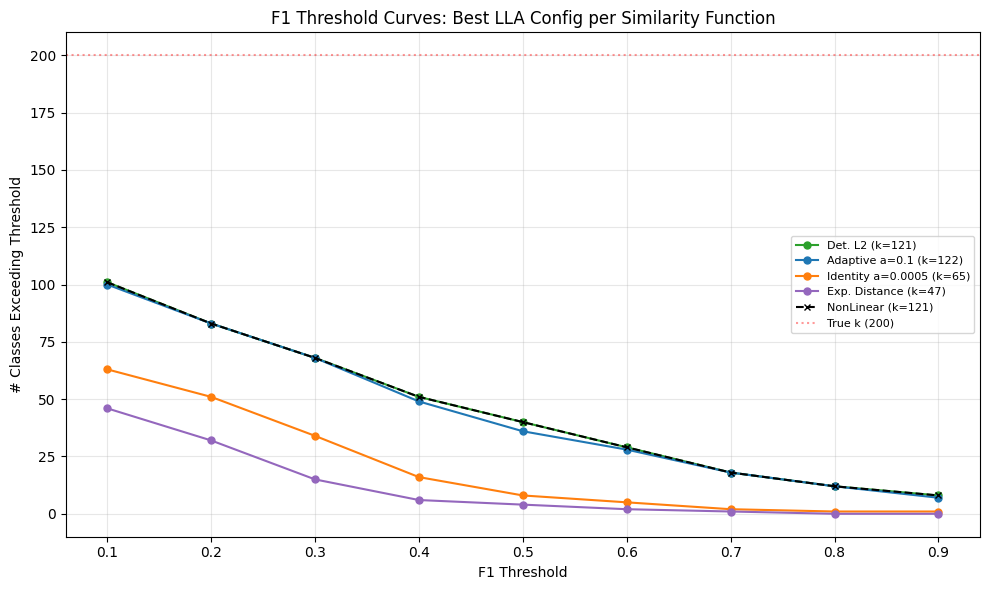

In [10]:
# Pick best config per k_form (by F1>0.5)
best_per_kform = {}
for label, s in results.items():
    kf = s['k_form']
    if kf not in best_per_kform or s['r']['counts'][4] > best_per_kform[kf][1]['r']['counts'][4]:
        best_per_kform[kf] = (label, s)

thresholds = r_nl['thresholds']
colors = {'det_l2': 'tab:green', 'adaptive': 'tab:blue',
          'identity': 'tab:orange', 'expected_distance': 'tab:purple'}

fig, ax = plt.subplots(figsize=(10, 6))

for kf, (label, s) in best_per_kform.items():
    ax.plot(thresholds, s['r']['counts'], 'o-', color=colors.get(kf, 'gray'),
            markersize=5, label=f'{label} (k={s["k"]})')

ax.plot(thresholds, r_nl['counts'], 'x--', color='black', markersize=5,
        label=f'NonLinear (k={k_nl})')
ax.axhline(n_species, ls=':', color='red', alpha=0.4, label=f'True k ({n_species})')

ax.set_xlabel('F1 Threshold')
ax.set_ylabel('# Classes Exceeding Threshold')
ax.set_title('F1 Threshold Curves: Best LLA Config per Similarity Function')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Auto-Calibrated Scale vs Configuration

The auto-calibrated scale reflects the raw distance distribution.
Very different scales indicate fundamentally different distance geometries.

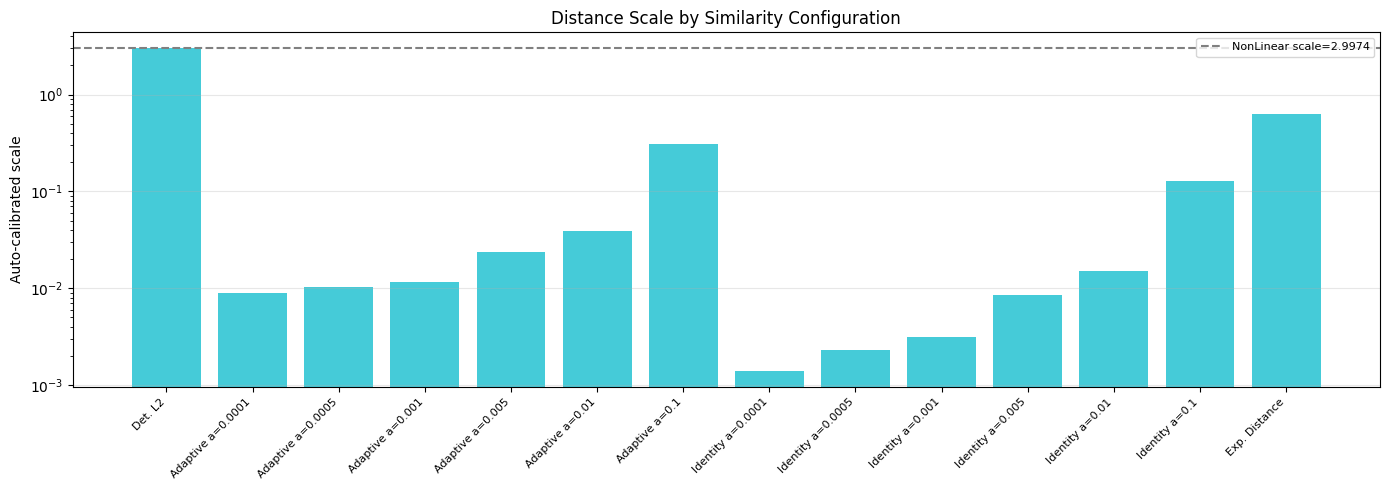

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

labels_list = list(results.keys())
scales = [results[l]['scale'] for l in labels_list]

bars = ax.bar(range(len(labels_list)), scales, color='tab:cyan', alpha=0.8)
ax.axhline(scale_nl, ls='--', color='gray', label=f'NonLinear scale={scale_nl:.4f}')

ax.set_xticks(range(len(labels_list)))
ax.set_xticklabels(labels_list, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Auto-calibrated scale')
ax.set_title('Distance Scale by Similarity Configuration')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Selective Prediction

Use LLA variance as a rejection signal with the **NonLinear deterministic clustering** as base.
This tests whether LLA uncertainty is useful for identifying unreliable predictions,
regardless of which similarity function is used for clustering.

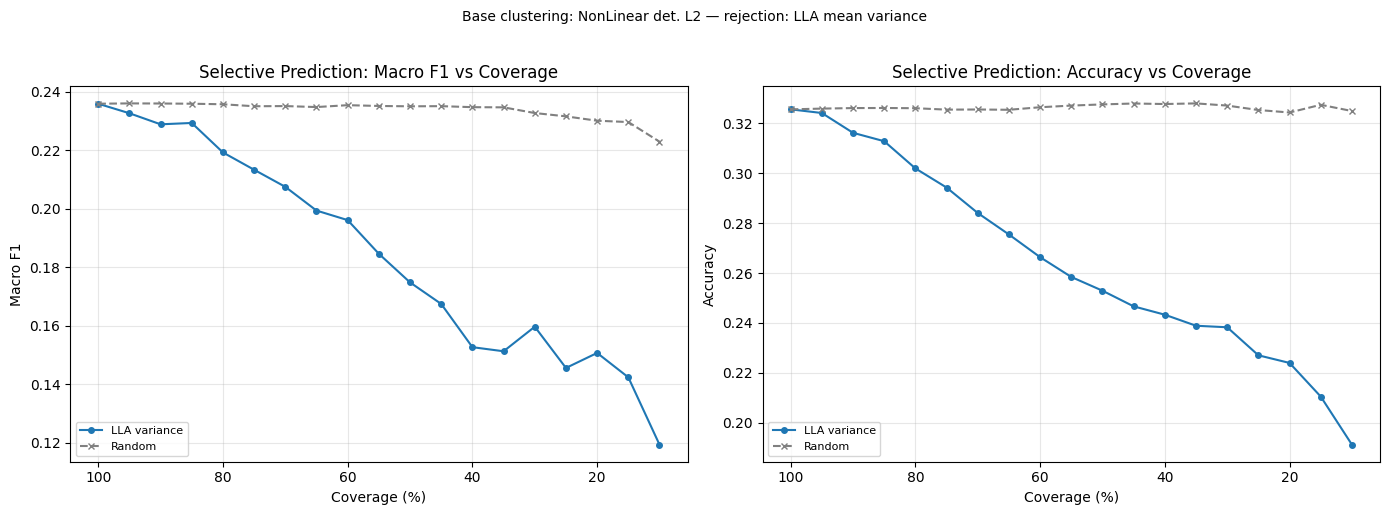

          F1@100%  F1@80%  F1@60%  F1@40%  |  Acc@100%  Acc@80%  Acc@60%  Acc@40%
-----------------------------------------------------------------
     LLA   0.236   0.219   0.196   0.153  |   0.326   0.302   0.266   0.243
  Random   0.236   0.236   0.235   0.235  |   0.326   0.326   0.326   0.328


In [12]:
def selective_curves(true_labels, pred_labels, uncertainties, coverages, alignment):
    n = len(true_labels)
    order = np.argsort(uncertainties)
    f1_scores, acc_scores = [], []
    for cov in coverages:
        k = max(1, int(n * cov))
        keep = order[:k]
        tl, pl = true_labels[keep], pred_labels[keep]
        mask = pl != -1
        if mask.sum() < 2:
            f1_scores.append(0.0); acc_scores.append(0.0)
            continue
        tl_m, pl_m = tl[mask], pl[mask]
        aligned = np.array([alignment.get(p, -1) for p in pl_m])
        per_f1 = sklearn.metrics.f1_score(tl_m, aligned, average=None, zero_division=0)
        f1_scores.append(np.mean(per_f1))
        acc_scores.append(np.mean(aligned == tl_m))
    return np.array(f1_scores), np.array(acc_scores)

# Base alignment from NonLinear clustering
mask_base = pred_nl != -1
base_alignment = align_labels_via_hungarian_algorithm(test_labels[mask_base], pred_nl[mask_base])
coverages_d = np.linspace(1.0, 0.1, 19)

# LLA uncertainty = mean variance per sample
lla_unc = test_emb_lla.variance.mean(axis=1)
f1_lla, acc_lla = selective_curves(test_labels, pred_nl, lla_unc, coverages_d, base_alignment)

# Random baseline
rng_d = np.random.RandomState(SEED)
rand_f1_list, rand_acc_list = [], []
for _ in range(20):
    rand_unc = rng_d.rand(len(test_labels))
    f1_r, acc_r = selective_curves(test_labels, pred_nl, rand_unc, coverages_d, base_alignment)
    rand_f1_list.append(f1_r); rand_acc_list.append(acc_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lla_vals, rand_vals, ylabel, title in zip(
        axes,
        [f1_lla, acc_lla],
        [rand_f1_list, rand_acc_list],
        ['Macro F1', 'Accuracy'],
        ['Macro F1 vs Coverage', 'Accuracy vs Coverage']):
    ax.plot(coverages_d * 100, lla_vals, 'o-', color='tab:blue',
            label='LLA variance', markersize=4)
    ax.plot(coverages_d * 100, np.mean(rand_vals, axis=0), 'x--', color='gray',
            label='Random', markersize=4)
    ax.set_xlabel('Coverage (%)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Selective Prediction: {title}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()

plt.suptitle('Base clustering: NonLinear det. L2 — rejection: LLA mean variance',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

# Summary at key coverages
key_covs = [100, 80, 60, 40]
idx_map = {round(c * 100): i for i, c in enumerate(coverages_d)}
print(f'{"":>8s}  ' + '  '.join(f'F1@{c}%' for c in key_covs)
      + '  |  ' + '  '.join(f'Acc@{c}%' for c in key_covs))
print('-' * 65)
f1_v = '  '.join(f'{f1_lla[idx_map[c]]:6.3f}' for c in key_covs)
acc_v = '  '.join(f'{acc_lla[idx_map[c]]:6.3f}' for c in key_covs)
print(f'{"LLA":>8s}  {f1_v}  |  {acc_v}')
f1_r = '  '.join(f'{np.mean(rand_f1_list, axis=0)[idx_map[c]]:6.3f}' for c in key_covs)
acc_r = '  '.join(f'{np.mean(rand_acc_list, axis=0)[idx_map[c]]:6.3f}' for c in key_covs)
print(f'{"Random":>8s}  {f1_r}  |  {acc_r}')

## Summary

This notebook tested LLA variance with all three probabilistic similarity functions
(adaptive, identity, expected_distance) at multiple scaling constants, compared against
the deterministic L2 baseline.

**Key questions answered:**

1. **Does the similarity function matter for LLA?** Yes — the adaptive form was previously
   found harmful because LLA's near-isotropic variance collapses the Mahalanobis distance
   to a per-sample scalar. Identity and expected_distance handle this differently.

2. **Does $\alpha$ matter?** For adaptive and identity forms, $\alpha$ controls how much
   variance influences the similarity. Large $\alpha$ converges to the deterministic baseline.

3. **Is LLA variance useful for selective prediction?** The selective prediction curves
   show whether LLA variance — regardless of its effect on clustering — provides a useful
   uncertainty ranking for identifying unreliable predictions.